# Lesson 4 : RNNs(Recurrent Neural Network) & LSTMs (Long Short Term Memory)

### Handling Sequences Through Time

We just saw that our neural bigram model only looks at one previous word. Real Language needs memory across an entire sequence. RNN were first architecture designed to solve exactly this - and understanding why they struggle is essential motivation for attention.


# The Core Idea -- Network With Memory

Imagine Reading a sentence word by word , and after eah word you update a mental notebooks summarizing everything so far.

Read "The"    ->  notebook : "Subject comming up"

Read "King"   ->  notebook : "Subject= king"

Read "rules"  -> notebook : "King is doing an action : ruling"

Read "the"    -> notebook : "king rules ___, object coming"

Read "Land"   -> notebook : "King rules the land" Full meaning

__That notebook is called hidden state. RNN=same neural network, reused at every word, always updating same hidden state.__


# RNN From Scratch

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleRNN(nn.Module):
    def __init__(self,vocab_size,embedding_dim,hidden_dim):
        super().__init__()
        # Key equation of RNN
        # h_t=tanh(W_x*x_t + w_h*h_{t-1})
        self.embed=nn.Embedding(vocab_size,embedding_dim)
        self.Wx=nn.Linear(embedding_dim,hidden_dim) #new word->hidden
        self.Wh=nn.Linear(hidden_dim,hidden_dim)  #oldmemory -> hidden
        self.output=nn.Linear(hidden_dim,vocab_size)
        self.hidden_dim=hidden_dim

    def forward(self,x):
        # x: (batch_size,seq_len)
        # hidden: (batch_size,hidden_dim)
        batch_size=x.size(0)
        h=torch.zeros(batch_size,self.hidden_dim)
        emb=self.embed(x)
        outputs=[]

        for t in range(emb.size(0)):
            x_t=emb[t].unsqueeze(0)
            h=torch.tanh(self.Wx(x_t)+self.Wh(h))
            logits_t=self.output(h)
            outputs.append(logits_t)
        return torch.cat(outputs,dim=0)


# --- Demo: predict next word at each position ---
vocab  = ["the","king","rules","land","with","wisdom","queen","advises"]
w2i    = {w:i for i,w in enumerate(vocab)}
i2w    = {i:w for w,i in w2i.items()}

sentence = "the king rules the land".split()
x = torch.tensor([w2i[w] for w in sentence])

model = SimpleRNN(vocab_size=len(vocab), embedding_dim=8, hidden_dim=16)
logits = model(x)
print("Input sentence:", sentence)
print("Output shape (seq_len, vocab_size):", logits.shape)
print("→ RNN gives a prediction at EVERY timestep, using memory of all previous words")





Input sentence: ['the', 'king', 'rules', 'the', 'land']
Output shape (seq_len, vocab_size): torch.Size([25, 8])
→ RNN gives a prediction at EVERY timestep, using memory of all previous words


__Start with [vocab_size ** 0.25 * 16], make sure it's smaller than your hidden dim, and if results are bad — double it and retrain. Embedding dim is one of the cheaper hyperparameters to tune because changing it doesn't restructure your whole model.__

# The Vanishing Gradient Problem

When training  RNNs on long sequences, the learning signal (gradient) shrinks to almost zero as it travels back through many time stamps.

WHY it happens: Backpropagation through time multiplies gradients at every step. If each multiplier is < 1 (common with tanh), after 50 steps you're multiplying 0.5 × 0.5 × 0.5... fifty times → basically zero. The model literally cannot learn long-range dependencies.

WHEN you see it: Sentences/documents longer than ~10-20 words. Early words get "forgotten" by the time the RNN reaches the end.

In [1]:
import torch

def simulate_gradient_flow(seq_len,multiplier=0.5):
    grad=1.0
    history=[grad]

    for _ in range(seq_len):
        grad*=multiplier
        history.append(grad)

    return history
short=simulate_gradient_flow(seq_len=10,multiplier=0.5)
long=simulate_gradient_flow(seq_len=100,multiplier=0.5)
print(f"Gradient strength over time (short sequence): {short[-1]:.6f}")
print(f"Gradient strength over time (long sequence): {long[-1]:.6f}")

Gradient strength over time (short sequence): 0.000977
Gradient strength over time (long sequence): 0.000000


__Simple memory hook: RNN = goldfish memory. Remembers the last few words clearly, forgets everything from a while ago.__

# LSTM (Long Short Term Memory)

An upgraded RNN with separate "Long-term Memory Highway"(cell state) plus 3 gates that control what to remember,forget and output.

WHY : To fix Vanishing Gradients. Instead of forcing information through squashing tanh every single step, LSTM gives gradients more direct path- like a conveyor belt that information can ride along mostly unchanged.

WHEN: Use when you need to remember things across longer sequences than plain RNN can handle (~100 words instead of ~10-20). Was the dominant architecture for NLP from 2014-2017, before Transformers replaced it.

# The Three Gates

Think of LSTMs Memory like diary with a smart editor deciding what to keep:

| Gate | Simple Meaning | Question it answers |
| :-----: | :-----: | :-----: |
| Forget Gate | Eraser | " What Old info should i throw away" |
| Input Gate | Pen | " What new info is worth to write down " |
| Output Gate | Highlighter | " What part of my notes do i need right now" |

-------------------------------------------------------------------------------------------------

In [3]:
import torch.nn as nn
class simpleLstm(nn.Module):
    def __init__(self,input_dim,hidden_dim):
        super().__init__()
        self.hidden_dim=hidden_dim
        #combine input +previous hidden state for all 4 gates
        self.gates=nn.Linear(input_dim+hidden_dim,4*hidden_dim)

    def forward(self,x,h_prev,c_prev):
        combined=torch.cat([x,h_prev],dim=1)
        gates=self.gates(combined)

        # split gates into 4 parts
        f_gate,g_gate,o_gate,i_gate=torch.split(gates,self.hidden_dim,dim=1)

        f_gate=torch.sigmoid(f_gate) # FORGET: 0=erase,1=keep (0 to 1)
        i_gate=torch.sigmoid(i_gate) # INPUT: 0=ignore,1=accept (0 to 1)
        g_gate=torch.tanh(g_gate) # Candidate New memory content 
        o_gate=torch.sigmoid(o_gate) # Output : 0= hide, 1=show

        # Update Long term memory 
        # this is a near linear path -> gradients floe much better

        c_new=f_gate*c_prev+i_gate*g_gate
        h_new=o_gate*torch.tanh(c_new)

        return h_new,c_new
    
cell=simpleLstm(input_dim=8,hidden_dim=16)
h=torch.zeros(1,16)
c=torch.zeros(1,16)
print("Hidden state (short-term):", h.shape)
print("Cell state   (long-term): ", c.shape)
print("\n→ c (cell state) is the 'memory highway' — info can flow")
print("  through many steps with minimal change, fixing vanishing gradients.")



Hidden state (short-term): torch.Size([1, 16])
Cell state   (long-term):  torch.Size([1, 16])

→ c (cell state) is the 'memory highway' — info can flow
  through many steps with minimal change, fixing vanishing gradients.


------------------------------------------------------------------------------------------------------

Why the cell state fixes vanishing gradients: __c_new = f_gate * c_prev + i_gate * g_gate__ is mostly addition, not repeated multiplication through tanh. Addition doesn't shrink gradients the way repeated multiplication does. Information has a shortcut path.

Simple memory hook: LSTM = goldfish + a notebook it can selectively write to and erase from. Much better memory, still struggles past ~100 words.

------------------------------------------------------------------------------------------------------

In [6]:
# Pytorch LSTM

import torch.nn as nn

class LSTMLanguageModel(nn.Module):
    def __init__(self,vocab_size,embedding_dim,hidden_dim,num_layers=1):
        super().__init__()
        self.embed=nn.Embedding(vocab_size,embedding_dim)
        # PyTorch's built-in LSTM — does everything above internally
        self.lstm=nn.LSTM(input_size=embedding_dim,hidden_size=hidden_dim,num_layers=num_layers,batch_first=True)
        self.fc=nn.Linear(hidden_dim,vocab_size)

    def forward(self,x,hidden=None):
        emb=self.embed(x)
        out,hidden=self.lstm(emb,hidden)
        logits=self.fc(out)
        return logits,hidden
        

vocab_size=100
model=LSTMLanguageModel(vocab_size=vocab_size,embedding_dim=8,hidden_dim=16)
x=torch.randint(0,vocab_size,(1,10))
logits,hidden=model(x)
print("Output shape:", logits.shape)  # (1, 10, 100) — prediction at every step
print("Hidden state:", hidden[0].shape, "+ Cell state:", hidden[1].shape)

        

Output shape: torch.Size([1, 10, 100])
Hidden state: torch.Size([1, 1, 16]) + Cell state: torch.Size([1, 1, 16])


# Bidirectional RNN/LSTM

WHAT: Run two RNNs — one reading left-to-right, one reading right-to-left — and combine their outputs.

WHY: Sometimes you need context from both directions. "The bank was steep" vs "The bank approved my loan" — to disambiguate "bank", you need to see the word after it too, not just before.

WHEN: Use for understanding tasks (classification, NER, BERT-style encoding) where you have the full sentence available. Never use for generation tasks — you can't see future words you haven't generated yet!

In [7]:
# Bidirectional LSTM
bilstm = nn.LSTM(input_size=32, hidden_size=64,batch_first=True, bidirectional=True)

x = torch.randn(1, 10, 32)  # batch=1, seq_len=10, embed_dim=32
out, (h, c) = bilstm(x)
print("Bidirectional output shape:", out.shape)  
# (1, 10, 128) ← 64*2, forward+backward concatenated
print("\n→ Each position now has info from BOTH directions")

Bidirectional output shape: torch.Size([1, 10, 128])

→ Each position now has info from BOTH directions


__Simple memory hook: Bidirectional = reading a sentence forwards AND backwards, then combining what you learned both ways.__

# Sequence-to-Sequence (Seq2Seq)

WHAT: Two RNNs/LSTMs chained together — an Encoder that reads the input sentence into one summary vector, and a Decoder that generates the output sentence from that summary.

WHY: Needed for tasks where input and output are different lengths/languages — translation, summarization. A single RNN can't naturally output a different-length sequence than its input.

WHEN: Translation, summarization, chatbots (2014-2017 era) — the direct ancestor of how modern LLMs are framed (though modern ones use Transformers, not RNNs).

In [2]:
import torch
import torch.nn as nn
class Seq2seq(nn.Module):
    def __init__(self,vocab_size,embedding_dim,hidden_dim):
        super().__init__()
        self.embed=nn.Embedding(vocab_size,embedding_dim)
        self.encoder=nn.LSTM(embedding_dim,hidden_dim,batch_first=True)
        self.decoder=nn.LSTM(embedding_dim,hidden_dim,batch_first=True)
        self.fc=nn.Linear(hidden_dim,vocab_size)


    def forward(self,src,tgt):
        # Encoder : read entire source sentence and compress into(h,c)

        src_emb=self.embed(src)
        _,(h,c)=self.encoder(src_emb)
        print(f"Encoder compressed input into hidden state : {h.shape}")
        print(f"ENTIRE sentence squeezed into ONE fixed-size vector!")

        # Decoder : Starts from encoder final state , generate output
        tgt_emb=self.embed(tgt)
        out,_=self.decoder(tgt_emb,(h,c))
        logits=self.fc(out)
        return logits
    
vocab_size=50
model=Seq2seq(vocab_size,embedding_dim=16,hidden_dim=32)
src=torch.randint(0,vocab_size,(1,8))
tgt=torch.randint(0,vocab_size,(1,6))
logits=model(src,tgt)
print(f"Output shape : {logits.shape}")



Encoder compressed input into hidden state : torch.Size([1, 1, 32])
ENTIRE sentence squeezed into ONE fixed-size vector!
Output shape : torch.Size([1, 6, 50])


# The Bottleneck Problem (Why Seq2Seq Fails on Long Sentences)

WHAT: The encoder must compress an ENTIRE sentence — no matter how long — into a single fixed-size vector.

WHY this is bad: Imagine compressing a 3-word sentence and a 100-word paragraph into the exact same size box. The 100-word paragraph loses massive amounts of detail. This is called the information bottleneck.

WHEN it bites you: Long sentences in translation — the beginning of the sentence gets "blurred out" by the time the encoder finishes reading, because everything is squeezed through one vector.

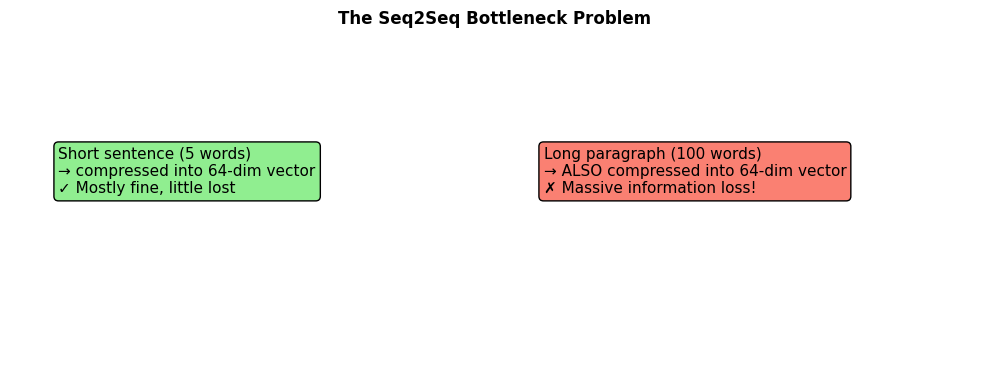

Saved to bottleneck.png


In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.text(0.05, 0.6, "Short sentence (5 words)\n→ compressed into 64-dim vector\n✓ Mostly fine, little lost",
        fontsize=11, va='center', bbox=dict(boxstyle="round", facecolor='lightgreen'))
ax.text(0.55, 0.6, "Long paragraph (100 words)\n→ ALSO compressed into 64-dim vector\n✗ Massive information loss!",
        fontsize=11, va='center', bbox=dict(boxstyle="round", facecolor='salmon'))
ax.set_title("The Seq2Seq Bottleneck Problem", fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig("bottleneck.png", dpi=150)
plt.show()
print("Saved to bottleneck.png")

# Attention (Preview — Full Lesson Next)

WHAT: Instead of forcing the decoder to use ONE fixed summary vector, let it look back at every word of the input at every decoding step, and decide which ones matter right now.

WHY: This completely removes the bottleneck. No more cramming everything into one vector — the decoder can directly access any input word it needs, whenever it needs it.

WHEN: This idea (2015) led directly to the Transformer (2017) — the architecture behind every modern LLM.

In [1]:
print("""
SEQ2SEQ WITHOUT ATTENTION:
  Encoder reads: "The king who fought the dragon ruled wisely"
  → squeezes EVERYTHING into ONE vector
  → Decoder must work from that one blurry summary

SEQ2SEQ WITH ATTENTION:
  Encoder reads: "The king who fought the dragon ruled wisely"
  → keeps a vector for EVERY word (not just one summary!)
  
  Decoder generating "wisely":
  → looks back at ALL words: king(0.1) who(0.0) fought(0.1) 
                              dragon(0.05) ruled(0.7) ← AHA, "ruled" matters most!
  → directly pulls information from "ruled" to predict "wisely"

  No bottleneck. No forgetting. Direct access to anything, anywhere.
""")


SEQ2SEQ WITHOUT ATTENTION:
  Encoder reads: "The king who fought the dragon ruled wisely"
  → squeezes EVERYTHING into ONE vector
  → Decoder must work from that one blurry summary

SEQ2SEQ WITH ATTENTION:
  Encoder reads: "The king who fought the dragon ruled wisely"
  → keeps a vector for EVERY word (not just one summary!)
  
  Decoder generating "wisely":
  → looks back at ALL words: king(0.1) who(0.0) fought(0.1) 
                              dragon(0.05) ruled(0.7) ← AHA, "ruled" matters most!
  → directly pulls information from "ruled" to predict "wisely"

  No bottleneck. No forgetting. Direct access to anything, anywhere.



# Full Lesson Cheat Sheet

| __Concept__ | __WHAT__ | __WHY__ | __WHEN to Use__ |
| :-----: | :-----: | :-----: | :-----: |
| RNN | Network with memory updated word by word | Bigram models have Zero memory | Short Sequences, Simple sequence task |
| Vanishing gradient | Learning signal shrinks to ~0 over long sequences | Repeated multiplication through tanh | Diagnose why RNN forgets early words |
| LSTM | RNN + gates + separate long-term memory | Fixes vanishing gradient via additive memory path | Sequences up to ~100 words, pre-2017 NLP |
| Forget/Input/Output gates | Eraser / Pen / Highlighter | Control what to keep, add, and reveal | Inside every LSTM cell |
| Bidirectional RNN | Read forward AND backward, combine | Some tasks need future context too | Classification understanding, NOT generation |
| Seq2Seq | Encoder compresses input → Decoder generates output | Input/output lengths differ (translation) | Translation, summarization (2014-2017) |
| Bottleneck problem | Entire sentence squeezed into 1 fixed vector | Long sentences lose information | Diagnose why long-sentence translation is bad |
| Attention | Decoder looks back at every input word directly | Removes the bottleneck entirely | The bridge straight into Transformers |
